<a href="https://colab.research.google.com/github/hiranshree/webtemp1/blob/main/preprocessing_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# 1. FORMATTING
# ==========================================
def preprocess_formatting(df):
    """Initial cleanup: standardize timestamps and ensure numeric data."""
    if 'Timestamp' not in df.columns:
        df = df.rename(columns={df.columns[0]: 'Timestamp'})
    df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
    df = df.dropna(subset=['Timestamp']).drop_duplicates(subset=['Timestamp'])
    df = df.set_index('Timestamp').sort_index()
    df = df.apply(pd.to_numeric, errors='coerce')
    df = df * 0.001  # Convert from Wh to kWh
    return df.round(4)

# ==========================================
# 2. INCLUSION LOGIC (With Analysis Report)
# ==========================================
def identify_qualified_buildings(df, threshold=11.0, global_nan_limit=11.0):
    """
    Must pass TWO tests:
    1. Overall missing data (NaNs) across the whole timeline must be <= 10%.
    2. Must have at least one continuous 180-day window with <= 10% bad data.
    """
    analysis_report = []
    accepted_cols = []
    window_intervals = 180 * 24 # 4320 hourly intervals

    if len(df) < window_intervals:
        print(f"Dataframe length ({len(df)}) is shorter than 180 days ({window_intervals}).")
        return pd.DataFrame(), pd.DataFrame()

    for col in df.columns:
        series = df[col]

        is_null = series.isna()
        is_zero = (series == 0)
        m, s = series.mean(), series.std()
        is_outlier = (series > m + 3*s) | (series < m - 3*s)

        # --- FIX 1: Add the Global Check ---
        global_missing_pct = (is_null.sum() / len(df)) * 100
        passes_global = global_missing_pct <= global_nan_limit

        # --- FIX 2: Window Check ---
        bad_mask = is_null | is_zero | is_outlier
        bad_rate_rolling = bad_mask.rolling(window=window_intervals, min_periods=window_intervals).mean() * 100
        best_window_error = round(bad_rate_rolling.min(), 2) if not bad_rate_rolling.dropna().empty else 100.0

        passes_window = (bad_rate_rolling <= threshold).any()

        # Must pass BOTH the global check and the window check
        if passes_global and passes_window:
            accepted_cols.append(col)
            status = "ACCEPTED"
            print(f"ACCEPTED: {col}")
        else:
            reasons = []
            if not passes_global: reasons.append(f"Global Missing ({global_missing_pct:.1f}%) > {global_nan_limit}%")
            if not passes_window: reasons.append(f"Best window bad data ({best_window_error}%) > {threshold}%")
            status = f"REJECTED: {', '.join(reasons)}"
            print(f"REJECTED: {col} ({status})")

        analysis_report.append({
            'Building': col,
            'Global_Missing_%': round(global_missing_pct, 2),
            'Zeros_%': round((is_zero.sum()/len(df))*100, 2),
            'Outliers_%': round((is_outlier.sum()/len(df))*100, 2),
            'Best_6Mo_Window_Bad_%': best_window_error,
            'Status': status
        })

    return df[accepted_cols], pd.DataFrame(analysis_report)

# ==========================================
# 3. CONSOLIDATED MERGING & SAVING
# ==========================================
def finalize_and_save(df_filtered, base_path='processed'):
    """Resamples and saves the consolidated data."""
    resolutions = {'15min':'15T','30min':'30T','hourly': 'H'}
    # df_cleaned = df_filtered.replace(0, np.nan)

    for label, res_code in resolutions.items():
        # Aggregating using sum with min_count=1 to keep NaNs accurate
        resampled = df_filtered.resample(res_code).sum(min_count=1).round(4)
        resampled = resampled.dropna(how='all')
        resampled.index.name = 'Timestamp'

        folder = os.path.join(base_path, label)
        os.makedirs(folder, exist_ok=True)

        csv_path = os.path.join(folder, f"Electricity-{label}.csv")
        parquet_path = os.path.join(folder, f"Electricity-{label}.parquet")
        resampled.to_csv(csv_path, index=True)
        resampled.to_parquet(parquet_path, index=True)
        print(f"Saved {label} consolidated file.")

# ==========================================
# MAIN PIPELINE
# ==========================================
def run_pipeline():
    # Load raw data
    input_file = '/content/Electricity.csv'
    if not os.path.exists(input_file):
        print(f"Error: {input_file} not found.")
        return

    df_raw = pd.read_csv(input_file)
    df_fmt = preprocess_formatting(df_raw)

    # Step 2: Quality Filtering & Report Generation
    df_qualified, report = identify_qualified_buildings(df_fmt, threshold=11.0)

    # Save the detailed quality report
    report.to_csv('data_quality_analysis.csv', index=False)
    print("Saved data_quality_analysis.csv")

    if not df_qualified.empty:
        # Step 3: Resample and Save
        finalize_and_save(df_qualified)
        print("\nProcessing complete. Qualified buildings preserved.")
    else:
        print("\nNo buildings met the criteria.")

if __name__ == "__main__":
    run_pipeline()

ACCEPTED: municipal library
ACCEPTED: house_1
ACCEPTED: house_2
ACCEPTED: house_3
ACCEPTED: house_4
ACCEPTED: house_5
ACCEPTED: house_6
ACCEPTED: house_7
ACCEPTED: house_8
ACCEPTED: house_9
ACCEPTED: house_10
ACCEPTED: house_11
ACCEPTED: house_12
ACCEPTED: house_13
ACCEPTED: house_14
ACCEPTED: house_15
ACCEPTED: house_16
ACCEPTED: house_17
ACCEPTED: house_18
ACCEPTED: house_19
ACCEPTED: house_20
ACCEPTED: house_21
ACCEPTED: house_22
ACCEPTED: house_23
ACCEPTED: house_24
ACCEPTED: house_25
ACCEPTED: house_26
ACCEPTED: house_27
ACCEPTED: house_28
ACCEPTED: house_29
ACCEPTED: house_30
ACCEPTED: house_31
ACCEPTED: house_32
ACCEPTED: house_33
ACCEPTED: house_34
ACCEPTED: house_35
ACCEPTED: house_36
ACCEPTED: house_37
ACCEPTED: house_38
ACCEPTED: house_39
ACCEPTED: house_40
ACCEPTED: house_41
ACCEPTED: house_42
ACCEPTED: house_43
ACCEPTED: house_44
ACCEPTED: house_45
ACCEPTED: house_46
ACCEPTED: house_47
ACCEPTED: house_48
ACCEPTED: house_49
ACCEPTED: house_50
Saved data_quality_analysis.csv

In [ ]:
df1 = pd.read_csv('/content/Electricity.csv')
df1.head()

,Timestamp,municipal library,house_1,house_2,house_3,house_4,house_5,house_6,house_7,house_8,...,house_41,house_42,house_43,house_44,house_45,house_46,house_47,house_48,house_49,house_50
0,2019-01-01 00:00:00,2.964,2.322959,1.544607,0.778310,1.962012,2.677445,0.237877,0.689194,0.358525,...,0.898895,0.203825,0.221624,0.319531,0.830996,0.924987,0.219128,0.274880,0.990488,0.779475
1,2019-01-01 00:15:00,2.584,2.371797,1.544607,0.778310,1.962012,2.733737,0.192929,0.558967,0.358525,...,0.917793,0.165311,0.179747,0.319531,0.848467,0.944434,0.177722,0.222940,1.011313,0.795863
2,2019-01-01 00:30:00,3.071,2.415961,1.319880,0.665072,1.676555,2.784640,0.382869,1.109272,0.377198,...,0.934883,0.328060,0.356708,0.336174,0.864266,0.962019,0.352691,0.442426,1.030144,0.810682
3,2019-01-01 00:45:00,2.694,2.302538,1.319880,0.665072,1.676555,2.653908,0.442052,1.280743,0.377198,...,0.890992,0.378772,0.411848,0.336174,0.823691,0.916855,0.407209,0.510816,0.981781,0.772623
4,2019-01-01 01:00:00,2.569,2.363063,0.913154,0.460128,1.159919,2.723669,0.192242,0.556976,0.668500,...,0.914413,0.164722,0.179106,0.595793,0.845343,0.940956,0.177089,0.222146,1.007588,0.792932


Generating heatmap for 51 buildings...


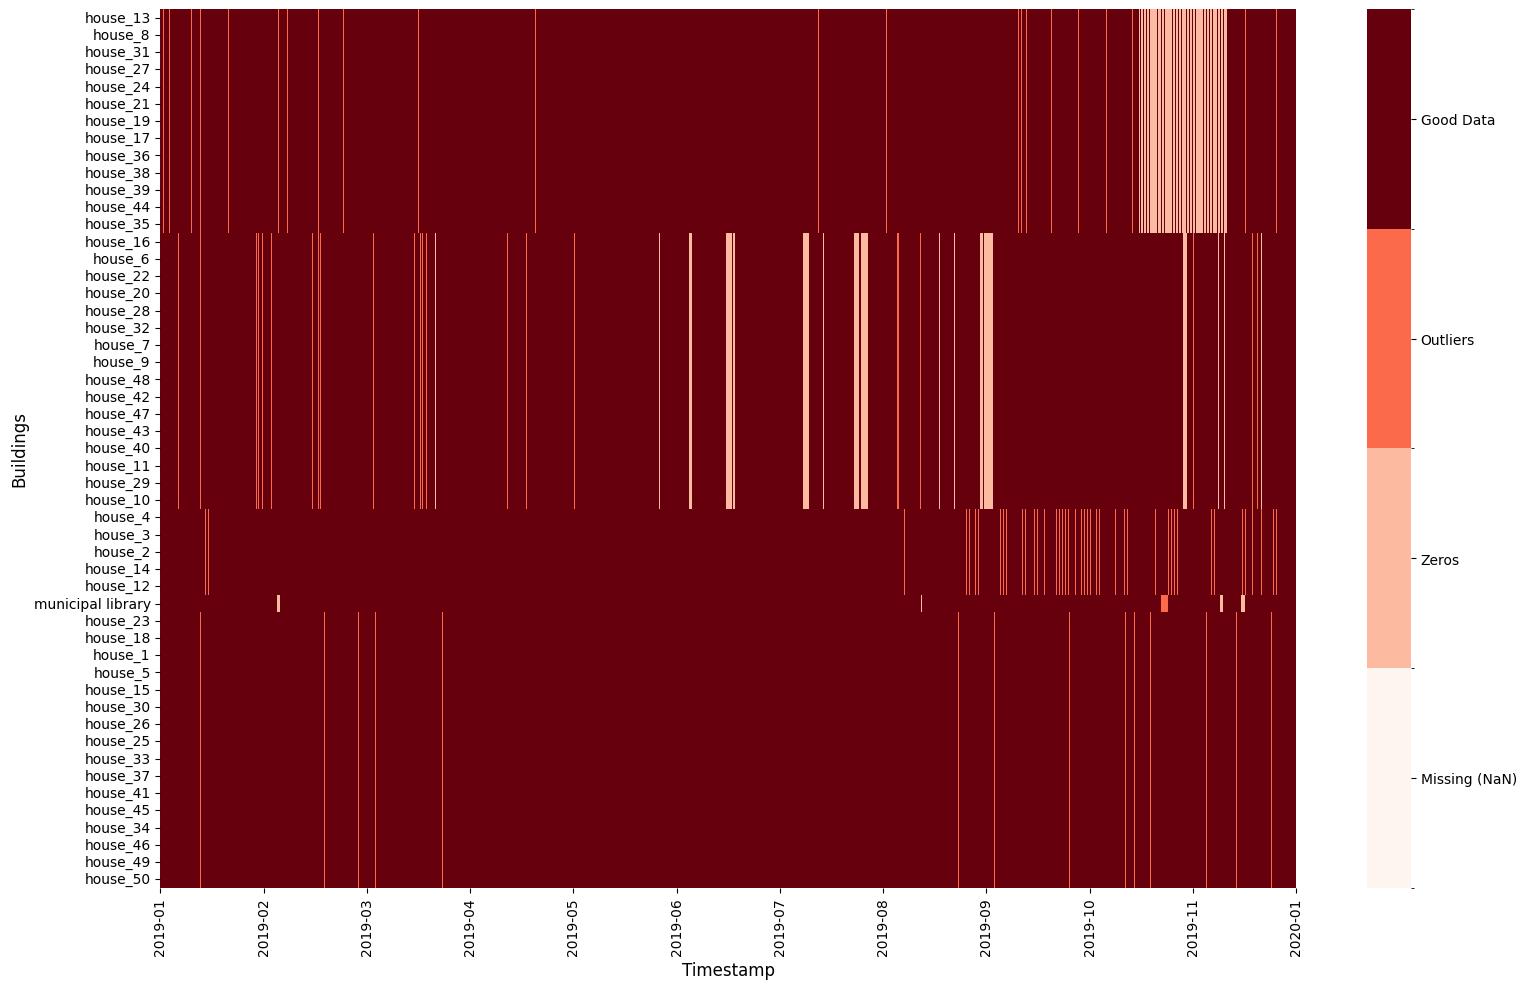

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

def plot_data_quality_heatmap(df, title=""):

    # 1. Create masks efficiently
    is_null = df.isna().values
    is_zero = (df == 0).values

    # Calculate outliers column-wise
    m = df.mean()
    s = df.std()
    is_outlier = ((df > m + 3*s) | (df < m - 3*s)).values

    # 2. Re-map numeric values (int8 saves RAM)
    # 0 = Missing, 1 = Zeros, 2 = Outliers, 3 = Good Data
    quality_grid = np.full(df.shape, 3, dtype=np.int8)
    quality_grid[is_null] = 0
    quality_grid[is_zero] = 1
    quality_grid[is_outlier] = 2

    # Create the quality DataFrame
    temp_quality_df = pd.DataFrame(quality_grid, index=df.index, columns=df.columns)

    # --- 3. ASCENDING SORT LOGIC ---
    # Count occurrences of '3' (Good Data) for each building
    good_data_counts = (temp_quality_df == 3).sum().sort_values(ascending=True)
    sorted_buildings = good_data_counts.index

    # Reorder the buildings: Least good data at the top (start of list), most at bottom
    plot_df = temp_quality_df[sorted_buildings].T

    # 4. SAFE VISUALIZATION LOGIC
    num_buildings = len(plot_df.index)
    dynamic_height = max(10, num_buildings * 0.05)
    dynamic_height = min(300, dynamic_height)

    print(f"Generating heatmap for {num_buildings} buildings...")
    plt.figure(figsize=(16, dynamic_height))

    colors = ["#fff5f0", "#fcbba1", "#fb6a4a", "#67000d"]
    cmap = mcolors.ListedColormap(colors)
    bounds = [0, 1, 2, 3, 4]
    norm = mcolors.BoundaryNorm(bounds, cmap.N)

    # 5. Generate Heatmap
    ax = sns.heatmap(plot_df, cmap=cmap, norm=norm,
                     rasterized=True,
                     cbar_kws={
                         'label': '',
                         'ticks': [0.5, 1.5, 2.5, 3.5]
                     })

    # 6. Customize Legend
    colorbar = ax.collections[0].colorbar
    colorbar.set_ticklabels(['Missing (NaN)', 'Zeros', 'Outliers', 'Good Data'])

    # 7. Formatting
    plt.title("", fontsize=16, pad=20)
    plt.xlabel("Timestamp", fontsize=12)
    plt.ylabel("Buildings", fontsize=12)

    xticks = np.linspace(0, len(df.index) - 1, 12).astype(int)
    ax.set_xticks(xticks)
    ax.set_xticklabels(df.index[xticks].strftime('%Y-%m'), rotation=90)

    plt.tight_layout()

    output_path = 'ECCG_data_quality_heatmap.png'
    plt.savefig(output_path, dpi=120, bbox_inches='tight')
    plt.show()
    plt.close()

if __name__ == '__main__':
    df_raw = pd.read_csv('/content/Electricity.csv', index_col='Timestamp', parse_dates=True)
    plot_data_quality_heatmap(df_raw)